## TASK 12. RAG Q&A CHATBOT
### Objective :

Build a document-based Retrieval-Augmented Generation (RAG) chatbot using LangChain and ChromaDB.

The chatbot retrieves relevant information from a document collection before generating answers with a Large Language Model.

The application is deployed using Streamlit to provide an interactive user interface.

## Notebook Structure :
- Objective
- Install Libraries
- Import Libraries
- Load API Key
- Load Documents
- Split Documents
- Generate Embeddings
- Create Vector Database
- Create Retriever
- Build RAG Pipeline
- Build Streamlit Chatbot
- Run Application
- Analysis
- Conclusion

## Step 1: Install Required Libraries

This project requires several libraries for building the RAG pipeline.

The following libraries are installed:

- LangChain for RAG workflow orchestration.
- LangChain OpenAI for OpenAI integrations.
- LangChain Community for document loaders and vector stores.
- ChromaDB for vector database storage.
- Streamlit for building the chatbot interface.
- Python-dotenv for loading API keys securely.

In [15]:
!pip install langchain
!pip install langchain-openai
!pip install langchain-community
!pip install chromadb
!pip install python-dotenv
!pip install streamlit


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Import Libraries

The required modules are imported to perform the following tasks:

- Load environment variables.
- Read and process documents.
- Split documents into chunks.
- Generate embeddings.
- Create the vector database.
- Build the retrieval chain.
- Develop the chatbot interface.

These libraries form the foundation of the Retrieval-Augmented Generation pipeline.

In [ ]:
import os
from dotenv import load_dotenv

from langchain_community.document_loaders import TextLoader

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_openai import OpenAIEmbeddings
from langchain_openai import ChatOpenAI

from langchain_community.vectorstores import Chroma


from langchain_classic.chains import RetrievalQA



C:\Users\tfd570\AppData\Local\Temp\ipykernel_5088\693998462.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader
c:\Users\tfd570\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 3: Load OpenAI API Key


In [3]:
from openai import OpenAI  

load_dotenv()

# Get the OpenAI API keys from environment variables
openai_api_key = os.getenv("API_KEY")

# Let's configure the OpenAI Client using our key
openai_client = OpenAI(api_key=openai_api_key)
print("OpenAI client successfully configured.")

OpenAI client successfully configured.


## Step 4: Load Restaurant Documents

The restaurant dataset is loaded using LangChain's TextLoader.

The file contains information about Eleven Madison Park, including:

- Restaurant details
- Chef information
- Menu and dining experience
- Restaurant philosophy

The loaded document serves as the external knowledge source for the RAG system.

In [4]:
# Define the path to your data file
# Ensure 'eleven_madison_park_data.txt' is in the same folder as this notebook
DATA_FILE_PATH = "eleven_madison_park_data.txt"
print(f"Data file path set to: {DATA_FILE_PATH}")

Data file path set to: eleven_madison_park_data.txt


In [5]:
# Let's load Eleven Madison Park Restaurant data, which has been scraped from their website
# The data is saved in "eleven_madison_park_data.txt", Langchain's TextLoader makes this easy to read
print(f"Attempting to load data from: {DATA_FILE_PATH}")

# Initialize the TextLoader with the file path and specify UTF-8 encoding
# Encoding helps handle various characters correctly
loader = TextLoader(DATA_FILE_PATH, encoding = "utf-8")

# Load the document(s) using TextLoader from LangChain, which loads the entire file as one Document object
raw_documents = loader.load()
print(f"Successfully loaded {len(raw_documents)} document(s).")


Attempting to load data from: eleven_madison_park_data.txt
Successfully loaded 1 document(s).


In [6]:
# Let's display a few characters of the loaded content to perform a sanity check!
print(raw_documents[0].page_content[:500] + "...")

Source: https://www.elevenmadisonpark.com/
Title: Eleven Madison Park
Content:
Book on Resy
---END OF SOURCE---

Source: https://www.elevenmadisonpark.com/careers
Title: Careers — Eleven Madison Park
Content:
Join Our Team Eleven Madison Park ▾ All Businesses Eleven Madison Park Clemente Bar Daniel Humm Hospitality Filter Categories Culinary Pastry Wine & Beverage Dining Room Office & Admin Other Job Types Full Time Part Time Compensation Salary Hourly Apply filters OPEN OPPORTUNITIES Staff Acco...


## Step 5: Split Documents into Chunks

In [7]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150
)

documents = text_splitter.split_documents(raw_documents)

print("Number of chunks:", len(documents))

Number of chunks: 38


## Step 6: Generate Embeddings

In [8]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=openai_api_key
)

print("Embeddings model loaded.")

Embeddings model loaded.


## Step 7: Create Vector Database

In [9]:
vector_store = Chroma.from_documents(
    documents=documents,
    embedding=embeddings
)

print("Vector database created successfully.")

Vector database created successfully.


## Step 8: Create Retriever

In [10]:
retriever = vector_store.as_retriever()

results = retriever.invoke(
    "Who is Daniel Humm?"
)

print(results[0].page_content)

Daniel Humm is a chef, author, speaker, and owner of Daniel Humm Hospitality , the New York-based hospitality group behind the highly acclaimed Eleven Madison Park, Clemente Bar , and direct-to-consumer lifestyle brand Eleven Madison Home . A native of Switzerland, Chef Humm earned his first Michelin star at the age of 24. He is consistently listed as one of the world’s best chefs, with both he and Eleven Madison Park receiving numerous accolades: four stars from The New York Times, seven James Beard Foundation Awards (including Outstanding Chef and Outstanding Restaurant in America), a number one spot on the world’s 50 Best Restaurants list, and three Michelin stars for over 12 years in a row, since 2012. At the height of the COVID-19 pandemic, Chef Humm transformed Eleven Madison Park’s Michelin-starred restaurant and its back-of-house into a commissary kitchen in partnership with Rethink Food , a not-for-profit organization co-founded by Chef Humm. He and his team prepared over


## Step 9: Build RAG Chain

In [11]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=openai_api_key,
    temperature=0
)
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=retriever
)
print("RAG chain created successfully.")

RAG chain created successfully.


## Step 10: Ask Questions

In [12]:
questions = [
    "Who is Daniel Humm?",
    "What type of restaurant is Eleven Madison Park?",
    "What food is served?",
    "What is the restaurant philosophy?"
]

for question in questions:
    answer = qa_chain.invoke(question)

    print("\nQuestion:", question)
    print("Answer:", answer["result"])


Question: Who is Daniel Humm?
Answer: Daniel Humm is a chef, author, speaker, and owner of Daniel Humm Hospitality, a New York-based hospitality group known for its acclaimed restaurant Eleven Madison Park, among others. He is originally from Switzerland and earned his first Michelin star at the age of 24. Humm has received numerous accolades, including four stars from The New York Times, seven James Beard Foundation Awards, and three Michelin stars for over 12 years. He is also known for his efforts during the COVID-19 pandemic, where he transformed Eleven Madison Park into a commissary kitchen to provide meals for frontline workers and underserved communities. In 2021, he reopened Eleven Madison Park with a completely plant-based menu, making it the first plant-based restaurant to receive a three-star rating from the Michelin Guide.

Question: What type of restaurant is Eleven Madison Park?
Answer: Eleven Madison Park is a fine dining restaurant that offers a fully plant-based menu,

## Step 11: Build Streamlit Chatbot

A Streamlit application is created to provide an interactive interface for the RAG system.

The application allows users to:

- Enter questions about Eleven Madison Park.
- Retrieve relevant document chunks.
- Generate answers using the RAG pipeline.
- Display both the generated answer and the retrieved context.

The Streamlit application is implemented in the `app.py` file.

## Step 12: Run the Streamlit Application

The chatbot application is launched using the Streamlit command.

Run the following command in the terminal:

```bash
streamlit run app.py
```
The application launches in your default web browser at:

http://localhost:8501

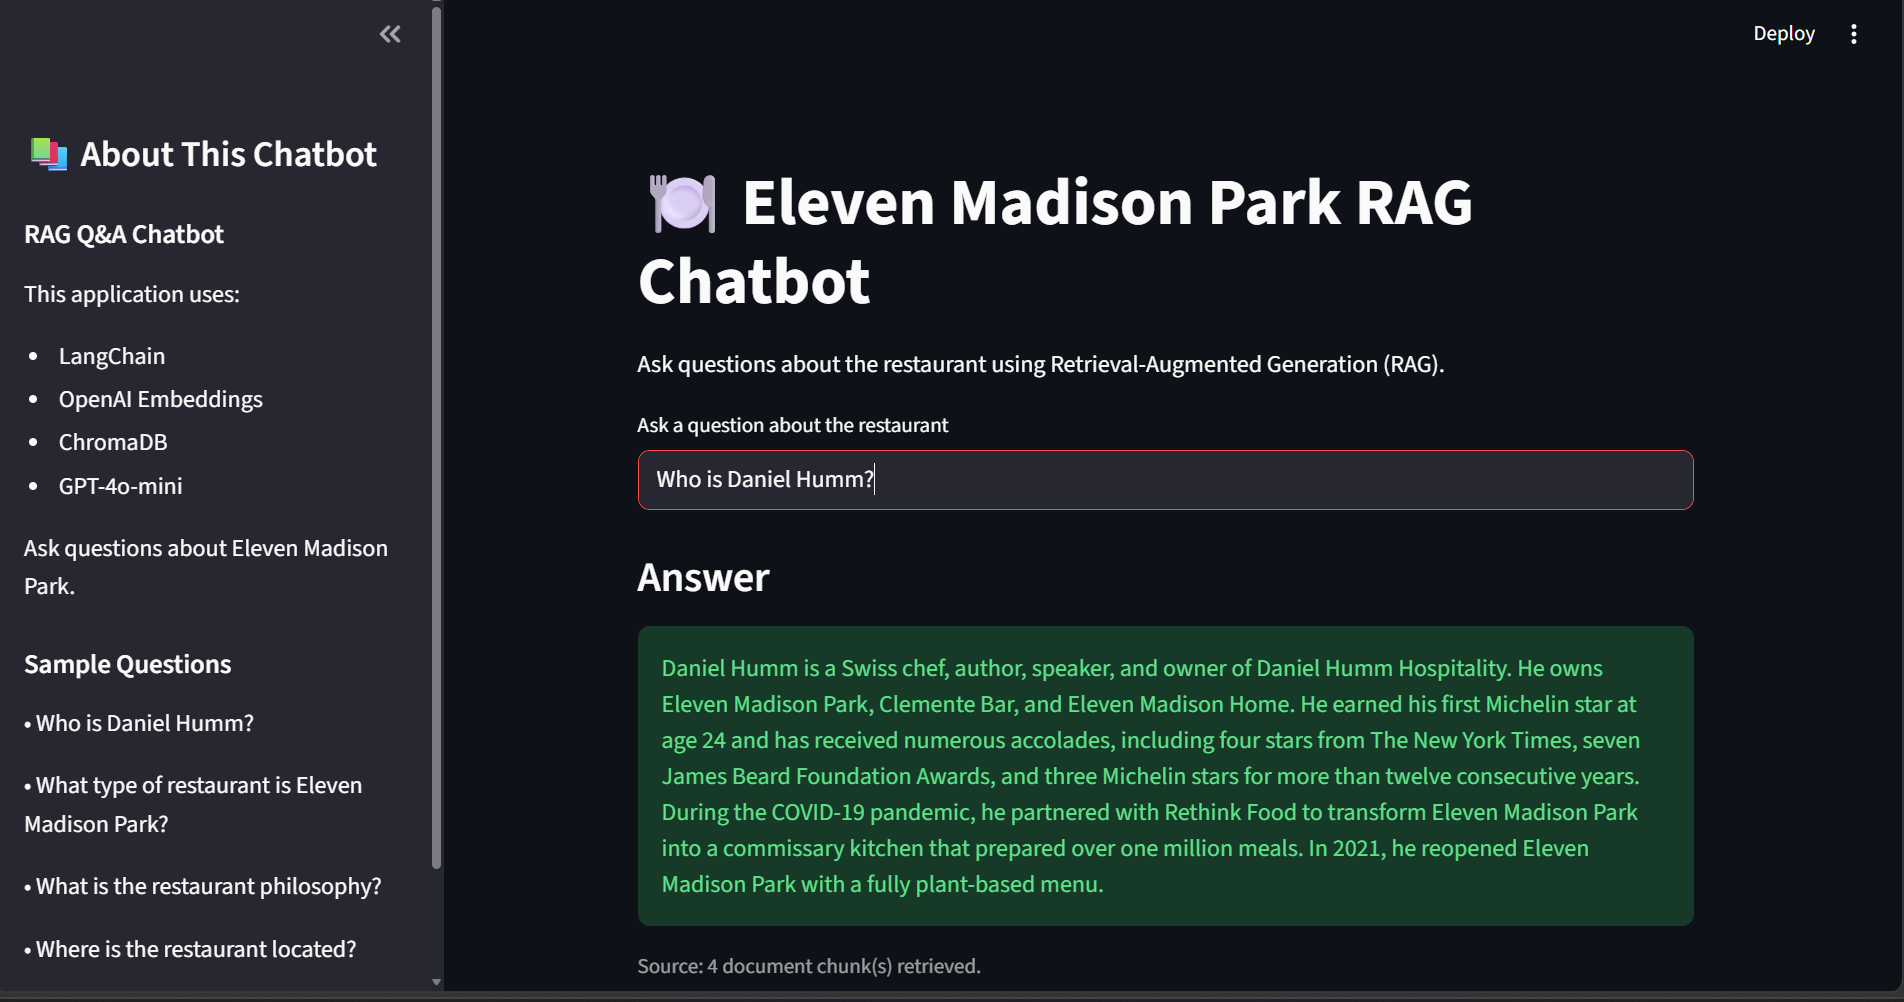

## Analysis

The RAG chatbot successfully retrieves relevant document chunks before generating answers.

Using LangChain with ChromaDB improves retrieval accuracy by providing the language model with contextual information instead of relying solely on its pretrained knowledge.

The Streamlit interface makes the chatbot interactive and user-friendly by allowing users to ask natural language questions and view both the generated answer and the retrieved context.

## Conclusion

A complete Retrieval-Augmented Generation (RAG) chatbot was successfully developed using LangChain, OpenAI Embeddings, ChromaDB, and GPT-4o-mini.

The application demonstrates how external documents can be integrated with a language model to provide accurate, context-aware responses.

Deploying the system with Streamlit provides an intuitive interface for real-time document-based question answering.